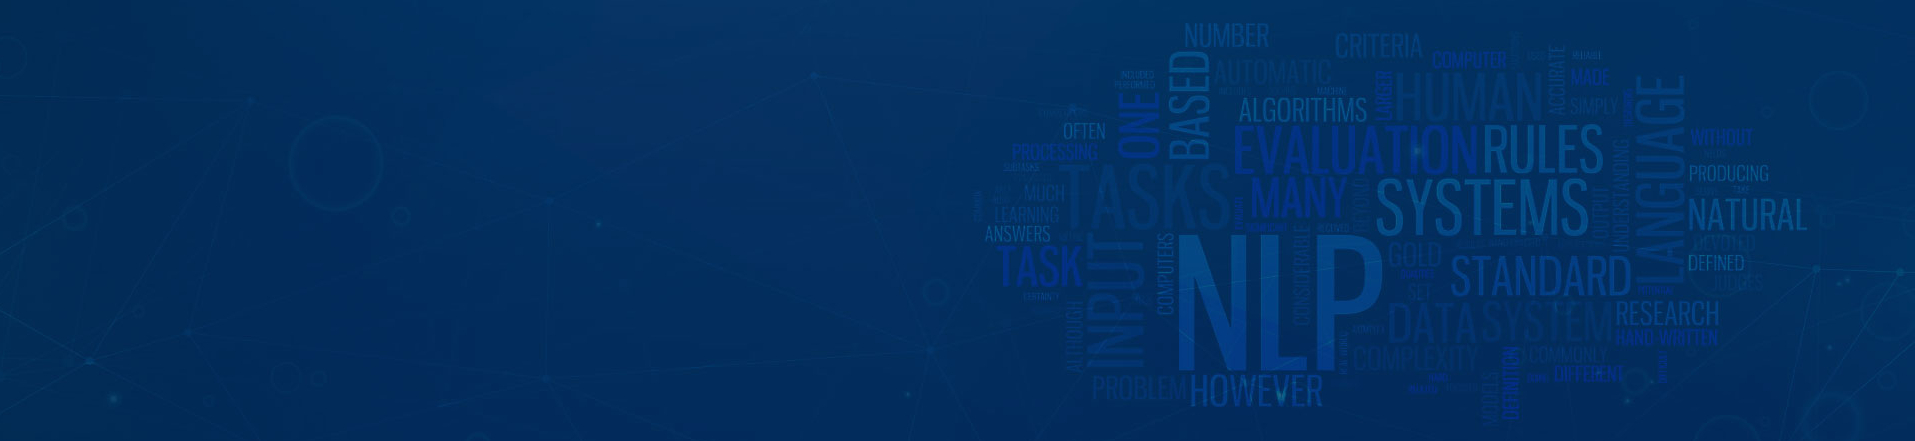

### Assignment 5

In this assignment we will do some exercises on phrase structure grammars and syntactic parsing, related to the lecture content of week 5.

**Exercise 1.** NLTK provides built-in methods to handle context-free grammars (CFG) which we will use here. Please consult the NLTK documentation for this exercise.
1. Import the ```CFG``` package and the ```generate``` function and ```demo_grammar``` from ```parse.generate```. Print out the demo grammar. How many production rules does the grammar have?
2. Print out the first 20 sentences that this grammar generates and inspect them. Are all these sentences grammatical English? Are all the sentences meaningful English? Support your answer with examples.
3. The depth of a sentence is the number of production rules that have been used to generate a sentence from a grammar. Print out the number of sentences with a maximum depth ranging from 1 to 8.
4. What is the total number of sentences that this grammar generates? Why is this number finite? Hint: you need to inspect the rules of the grammar to answer the second part of the question.<div style="text-align: right">**(4 points)**</div>

In [4]:
# your code here
import nltk
from nltk import CFG
from nltk.parse.generate import generate
from nltk.parse.generate import demo_grammar

grammar = CFG.fromstring(demo_grammar)
print(f"demo_grammar is a string that looks like this:\n{demo_grammar}")
print(f"The context free grammar based on demo_grammar is:\n{grammar}")
print(f"\nType of demo_grammar: {type(demo_grammar)}\nType of cfg grammar: {type(grammar)}")

# generating the first 20 sentences
sentences = list(generate(grammar))
#print(type(sentences), len(sentences))
print(f"\nThere are {len(sentences)} sentences in the grammar.\nThe first 20 sentences are:")
for i in range(0, 20):
    print(f"{i+1}. {' '.join(sentences[i])}")

# generating sentences with a maximum depth from 1 to 8
depth_1 = list(generate(grammar, depth = 1))
depth_2 = list(generate(grammar, depth = 2))
depth_3 = list(generate(grammar, depth = 3))
depth_4 = list(generate(grammar, depth = 4))
depth_5 = list(generate(grammar, depth = 5))
depth_6 = list(generate(grammar, depth = 6))
depth_7 = list(generate(grammar, depth = 7))
depth_8 = list(generate(grammar, depth = 8))

print(f"\nSentences with max depth 1: {len(depth_1)}")
print(f"Sentences with max depth 2: {len(depth_2)}")
print(f"Sentences with max depth 3: {len(depth_3)}")
print(f"Sentences with max depth 4: {len(depth_4)}")
print(f"Sentences with max depth 5: {len(depth_5)}")
print(f"Sentences with max depth 6: {len(depth_6)}")
print(f"Sentences with max depth 7: {len(depth_7)}")
print(f"Sentences with max depth 8: {len(depth_8)}")

#print(grammar.min_len())
#print(grammar.max_len())

demo_grammar is a string that looks like this:

  S -> NP VP
  NP -> Det N
  PP -> P NP
  VP -> 'slept' | 'saw' NP | 'walked' PP
  Det -> 'the' | 'a'
  N -> 'man' | 'park' | 'dog'
  P -> 'in' | 'with'

The context free grammar based on demo_grammar is:
Grammar with 13 productions (start state = S)
    S -> NP VP
    NP -> Det N
    PP -> P NP
    VP -> 'slept'
    VP -> 'saw' NP
    VP -> 'walked' PP
    Det -> 'the'
    Det -> 'a'
    N -> 'man'
    N -> 'park'
    N -> 'dog'
    P -> 'in'
    P -> 'with'

Type of demo_grammar: <class 'str'>
Type of cfg grammar: <class 'nltk.grammar.CFG'>

There are 114 sentences in the grammar.
The first 20 sentences are:
1. the man slept
2. the man saw the man
3. the man saw the park
4. the man saw the dog
5. the man saw a man
6. the man saw a park
7. the man saw a dog
8. the man walked in the man
9. the man walked in the park
10. the man walked in the dog
11. the man walked in a man
12. the man walked in a park
13. the man walked in a dog
14. the m

##### Answer Exercise 1:
1. The grammar has 13 productions
2. Grammatically all sentences are correct. They all follow the scheme NP VP which produces grammatically correct sentences, like "the man slept" or "the man saw a dog". However, not every sentence is meaningful. For example, the sentences "the man walked in the man" and "the man walked with the park" do not make sense. Other sentences like "the man saw the man" can make sense but still sound strange and out of context.
3. There are no sentences with a depth lower than 4. There are 6 sentences with depth 4, 42 sentences with a maximum depth of 5 and 114 sentences with a maximum depth of 6, 7, or 8.
4. This grammar generates 114 sentences. The amount of sentences generated is finite because the production rules do not allow for "circles", meaning that they all determinate at some point. The starting NP is always composed of Det N because it is the only rule for NP. There are only 2 Det and 3 N and all of them are terminal symbols. The VP is either a terminal, a terminal with a NP (which also terminates) or a terminal with a PP. The terminals are specified in the grammar and the PP results in P NP, where again NP terminates and P can be one out of two terminal symbols, meaning it also determinates. Since all rules terminate after a while, the possible amount of sentences is finite. <br>The most rules that can be applied are 9. For example: <br> start: NP VP <br>-> Det N VP <br>-> 'a' N VP <br>-> 'a' 'man' VP <br>-> 'a' 'man' 'walked' PP <br>-> 'a' 'man' 'walked' P NP <br>-> 'a' 'man' 'walked' 'with' NP <br>-> 'a' 'man' 'walked' 'with' Det N <br>-> 'a' 'man' 'walked' 'with' 'the' N <br>-> 'a' 'man' 'walked' 'with' 'the' 'dog'

**Exercise 2.** Next, we implement our own grammar with the following production rules, where set notation indicates that all elements of the set should be possible.

```S -> NP VP; VP -> {V NP, V NP PP}; PP -> P NP; V -> {"sees", "eats", "walks"}; NP -> {"he", "they", "Tom", "Alice", Det N, Det N PP}; Det -> {"a", "the", "my"}; N -> {"man", "dog", "cat", "telescope", "park"}; P -> {"in", "on", "with"}```

1. Use ```CFG.fromstring()``` to implement this grammar. Note, this can be done using 8 lines of code. Now determine the number of sentences of maximal depth 5 that are generated by this grammar and print it out. Why is that number so much larger than in the previous exercise?
2. When you inspect some of the sentences that this grammar generates, you will see that there are a number of *errors* with respect to English syntax. For example, the grammar generates the following ungrammatical sentences:
    1. *they walks a dog* and *they sees Alice* (subject and verb do not agree in number as they should)
    2. *Tom sees he* and *Tom sees they* (direct objects should be *him* and *them*)
    3. *Alice walks with he* and *a cat eats on they* (prepositional objects should be *him* and *them*)
3. Your task is to rewrite the grammar in such a way that these three issues are fixed. Note, even though you will have to add new words and replace some of the rules of the grammar, the new grammar should generate exactly as many sentences of depth 5 as the erroneous grammar. Verify this! If your new grammar generates a different number of such sentences, then your solution is most likely incorrect. For each of the errors A, B and C above, print out an example sentence from the new grammar that demonstrates that the error has been fixed.<div style="text-align: right">**(10 points)**</div>

In [7]:
# your code here
import re # you will need re.search to extract an example sentence in task no.3 above

# your code here

custom_grammar_string = """
S -> NP VP
VP -> V NP | V NP PP 
PP -> P NP 
V -> "sees" | "eats" | "walks"
NP -> "he" | "they" | "Tom" | "Alice" | Det N | Det N PP 
Det -> "a" | "the" | "my" 
N -> "man" | "dog" | "cat" | "telescope" | "park"
P -> "in" | "on" | "with"
"""

custom_grammar = CFG.fromstring(custom_grammar_string)
max_depth_5 = list(generate(custom_grammar, depth = 5))
#print(f"The cfg based on the custom grammar is:\n{custom_grammar}")
print(f"Sentences with max depth 5: {len(max_depth_5)}")

new_grammar_string = """
S -> NVSP E | NVPP E 
E -> NP | NP PP
PP -> P NP 
NP -> "him" | "them" | "Tom" | "Alice" | Det N | Det N PP 
NVSP -> NSingular VS | "Tom" VS | "Alice" VS | Det N VS | Det N PP VS
NVPP -> NPlural VP
VS -> "sees" | "eats" | "walks"
VP -> "see" | "eat" | "walk"
NName -> "Tom" | "Alice"
NSingular -> "he"
NPlural -> "they"
Det -> "a" | "the" | "my" 
N -> "man" | "dog" | "cat" | "telescope" | "park"
P -> "in" | "on" | "with"
"""

new_grammar = CFG.fromstring(new_grammar_string)
max_depth_5_new = list(generate(new_grammar, depth = 5))
#print(f"The cfg based on the custom grammar is:\n{new_grammar}")
print(f"New Sentences with max depth 5: {len(max_depth_5_new)}")


# showing the improvements
def find_sentences (all_sentences: list[list], first_word, second_word = None, third_word = None, fourth_word = None, fifth_word = None, sixth_word = None):
    wanted_sents = []
    min_length = 0
    if sixth_word != None:
        min_length = 6
    elif fifth_word != None:
        min_length = 5
    elif fourth_word != None:
        min_length = 4
    for element in all_sentences:
        general = len(element) >= min_length
        first = element[0] == first_word
        second = (second_word == None) or (element[1] == second_word)
        third = (third_word == None) or (element[2] == third_word)
        fourth = (fourth_word == None) or (general and element[3] == fourth_word)
        fifth = (fifth_word == None) or (general and element[4] == fifth_word)
        sixth = (sixth_word == None) or (general and element[5] == sixth_word)
        if first and second and third and fourth and fifth and sixth:
          wanted_sents.append(element) 
    return wanted_sents

Sentences with max depth 5: 147459
New Sentences with max depth 5: 147459


In [8]:
# Printing occurences (probably very inefficient way of doing this but it works)

# Problem A
sents_they_walks_old = find_sentences(max_depth_5, "they", "walks")
sents_they_walks_new = find_sentences(max_depth_5_new, "they", "walks")
sents_they_sees_old = find_sentences(max_depth_5, "they", "sees")
sents_they_sees_new = find_sentences(max_depth_5_new, "they", "sees")
sents_they_walk_old = find_sentences(max_depth_5, "they", "walk")
sents_they_walk_new = find_sentences(max_depth_5_new, "they", "walk")
sents_they_see_old = find_sentences(max_depth_5, "they", "see")
sents_they_see_new = find_sentences(max_depth_5_new, "they", "see")

print(f"\n\n\033[1m{"Examples":^22}{"Problem A: subject and verb incongruency": ^60}\033[0m")
print("="*82)
print(f"{"": ^22}|{"Occurences in old grammar": ^30}{"Occurences in new grammar": ^30}")
print("-"*82)
print(f"{"they walks": ^22}|{len(sents_they_walks_old): ^30}{len(sents_they_walks_new): ^30}")
print(f"{"they walk": ^22}|{len(sents_they_walk_old): ^30}{len(sents_they_walk_new): ^30}")
print(f"{"they sees": ^22}|{len(sents_they_sees_old): ^30}{len(sents_they_sees_new): ^30}")
print(f"{"they see": ^22}|{len(sents_they_see_old): ^30}{len(sents_they_see_new): ^30}")
print("-"*82)
print(f"Example sentence from old grammar: {' '.join(sents_they_sees_old[3])}")
print(f"Example sentence from new grammar: {' '.join(sents_they_see_new[3])}")

# Problem B
Tom_sees_he_old = find_sentences(max_depth_5, "Tom", "sees", "he")
Tom_sees_he_new = find_sentences(max_depth_5_new, "Tom", "sees", "he")
Tom_sees_him_old = find_sentences(max_depth_5, "Tom", "sees", "him")
Tom_sees_him_new = find_sentences(max_depth_5_new, "Tom", "sees", "him")
Tom_sees_they_old = find_sentences(max_depth_5, "Tom", "sees", "they")
Tom_sees_they_new = find_sentences(max_depth_5_new, "Tom", "sees", "they")
Tom_sees_them_old = find_sentences(max_depth_5, "Tom", "sees", "them")
Tom_sees_them_new = find_sentences(max_depth_5_new, "Tom", "sees", "them")

print(f"\n\n\033[1m{"Examples":^22}{"Problem B: wrong direct objects": ^60}\033[0m")
print("="*82)
print(f"{"": ^22}|{"Occurences in old grammar": ^30}{"Occurences in new grammar": ^30}")
print("-"*82)
print(f"{"Tom sees he": ^22}|{len(Tom_sees_he_old): ^30}{len(Tom_sees_he_new): ^30}")
print(f"{"Tom sees him": ^22}|{len(Tom_sees_him_old): ^30}{len(Tom_sees_him_new): ^30}")
print(f"{"Tom sees they": ^22}|{len(Tom_sees_they_old): ^30}{len(Tom_sees_they_new): ^30}")
print(f"{"Tom sees them": ^22}|{len(Tom_sees_them_old): ^30}{len(Tom_sees_them_new): ^30}")
print("-"*82)
print(f"Example sentence from old grammar: {' '.join(Tom_sees_they_old[0])}")
print(f"Example sentence from new grammar: {' '.join(Tom_sees_them_new[0])}")

# Problem C
Alice_walks_with_he_old = find_sentences(max_depth_5, "Alice", "walks", third_word = None, fourth_word = "with", fifth_word = "he")
Alice_walks_with_he_new = find_sentences(max_depth_5_new, "Alice", "walks", third_word = None, fourth_word = "with", fifth_word = "he")
Alice_walks_with_him_old = find_sentences(max_depth_5, "Alice", "walks", third_word = None, fourth_word = "with", fifth_word = "him")
Alice_walks_with_him_new = find_sentences(max_depth_5_new, "Alice", "walks", third_word = None, fourth_word = "with", fifth_word = "him")
cat_eats_on_they_old = find_sentences(max_depth_5, "a", "cat", "eats", fourth_word = None, fifth_word = "on", sixth_word = "they")
cat_eats_on_they_new = find_sentences(max_depth_5_new, "a", "cat", "eats", fourth_word = None, fifth_word = "on", sixth_word = "they")
cat_eats_on_them_old = find_sentences(max_depth_5, "a", "cat", "eats", fourth_word = None, fifth_word = "on", sixth_word = "them")
cat_eats_on_them_new = find_sentences(max_depth_5_new, "a", "cat", "eats", fourth_word = None, fifth_word = "on", sixth_word = "them")

print(f"\n\n\033[1m{"Examples":^22}{"Problem C: wrong prepositional objects": ^60}\033[0m")
print("="*82)
print(f"{"": ^22}|{"Occurences in old grammar": ^30}{"Occurences in new grammar": ^30}")
print("-"*82)
print(f"{"Alice walks _ with he": ^22}|{len(Alice_walks_with_he_old): ^30}{len(Alice_walks_with_he_new): ^30}")
print(f"{"Alice walks _ with him": ^22}|{len(Alice_walks_with_him_old): ^30}{len(Alice_walks_with_him_new): ^30}")
print(f"{"a cat eats _ on they": ^22}|{len(cat_eats_on_they_old): ^30}{len(cat_eats_on_they_new): ^30}")
print(f"{"a cat eats _ on them": ^22}|{len(cat_eats_on_them_old): ^30}{len(cat_eats_on_them_new): ^30}")
print("-"*82)
print(f"Example sentence from old grammar: {' '.join(Alice_walks_with_he_old[2])}")
print(f"Example sentence from new grammar: {' '.join(Alice_walks_with_him_new[2])}")



       Examples                 Problem A: subject and verb incongruency          
                      |  Occurences in old grammar     Occurences in new grammar   
----------------------------------------------------------------------------------
      they walks      |             247                            0               
      they walk       |              0                            247              
      they sees       |             247                            0               
       they see       |              0                            247              
----------------------------------------------------------------------------------
Example sentence from old grammar: they sees Alice
Example sentence from new grammar: they see Alice


       Examples                     Problem B: wrong direct objects               
                      |  Occurences in old grammar     Occurences in new grammar   
-----------------------------------------------------------

##### Answer Exercise 2:
1. There are many more sentences with a maximum depth of 5 because there are a lot more possibilities to form sentences. Instead of choosing between two terminal symbols for N or Det, there are now 3 options for Det and 5 options for N. This combined with more options for P, V, VP and NP accumulates the possibilities to from sentences.
2. The above table shows the improvements with the new grammar. The new grammar was verified to have as many sentences as the old grammar. <br> Note that the sentences "Alice walks with he" and "a cat eats on they" are not sentences that the grammar allows to begin with. The grammar allows sentences like "Alice walks _ with he" and "a cat eats _ on they" where the _ means that any noun can be substituted for it. <br>In the table above every problem mentioned previously is corrected which can be seen by the example sentences from the old and new grammar. In the table itself the number of occurences from parts of sentences are shown, so the sentence part "Tom sees he" appears 13 times in the old grammar and no time in the new grammar. This helps to visualize that the problems have actually been fixed.

We spent quite a lot of time on this exercise and are very happy that we got it to work. The code we wrote is neither efficient nor very nice to read and we apologize for this. We just do not have the energy to work more on this exercise...

**Exercise 3.** One important syntactic feature of English (and Dutch, and many other languages) is the existence of **relative clauses**. For example, in the sentence *'the raccoon that my sister chased kicked a ferret'*, the relative clause *'that my sister chased'* attaches to *'raccoon'* in the main clause *'the raccoon kicked a ferret'*. In this way, clauses can be nested within clauses and this particular syntactic construction is called **center embedding**. Relative clauses can also be attached at the end of another clause, for example in the sentence *'the raccoon kicked a ferret that my sister chased'* and this is called **right branching**. Note that this sentence uses the same two clauses as the previous one, but has a different meaning. Relative clauses can also be attached to nouns in other relative clauses, and so on, and this syntactic device can generate sentences that are very complicated and almost impossible to process by human brains.

In this exercise, your task is to come up with context-free grammar rules that generate sentences with relative clauses, as in the examples above, and can also generate relative clauses inside relative clauses, etc. Your grammar should be able to output complex sentences that are at least **30 words long**. Output from the grammar should, of course, be grammatical English. Hint: you can accomplish this task with just 4 production rules. 

NLTK does not provide a method to generate random sentences from a grammar. Therefore, we will have to use some custom code to accomplish this (see below). This will allow us to inspect *very, very, very, very, very, very long* sentences that grammars can generate.<div style="text-align: right">**(5 points)**</div>

In [11]:
import random
from collections import defaultdict

class myCFG(object):
    def __init__(self):
        self.prod = defaultdict(list)

    def add_prod(self, lhs, rhs):
        """ Add production to the grammar. 'rhs' can
            be several productions separated by '|'.
            Each production is a sequence of symbols
            separated by whitespace.

            Usage:
                grammar.add_prod('NT', 'VP PP')
        """
        prods = rhs.split('|')
        for prod in prods:
            self.prod[lhs].append(tuple(prod.split()))

    def gen_random(self, symbol):
        """ Generate a random sentence from the
            grammar, starting with the given symbol.
        """
        sentence = ''

        # select one production of this symbol randomly
        rand_prod = random.choice(self.prod[symbol])

        for sym in rand_prod:
            # for non-terminals, recurse
            if sym in self.prod:
                sentence += self.gen_random(sym)
            else:
                sentence += sym + ' '

        return sentence
    
my_cfg = myCFG()

# your code for the production rules here, the lexicon is already provided below

my_cfg.add_prod('Det', 'a | the | my | his | her | your | their')
my_cfg.add_prod('N', 'cat | dog | raccoon | ferret | horse | cow | mouse| boy | girl | grandma | father | mother | sister | brother')
my_cfg.add_prod('V', 'kicked | followed | shot | chased | hit | liked | saw | loved | hated | adored | carried | caught | joined | noticed')

# your code here
my_cfg.add_prod('S', 'NVP')
my_cfg.add_prod('NVP', 'NP V NP | NP Rel V NP | NP V NP Rel')
my_cfg.add_prod('NP', 'Det N')
my_cfg.add_prod('Rel', 'that NP V | that NP Rel V')

for i in range (0, 30):
    sentence = my_cfg.gen_random('S')
    print(f"{i+1}. ({len(sentence.split(" "))} words) {sentence}")

1. (6 words) her sister caught their brother 
2. (14 words) your cow loved their mouse that their grandma that my boy joined loved 
3. (26 words) your horse hated my cat that a dog that your mother that their dog that his sister that their father loved carried noticed carried caught 
4. (10 words) a grandma kicked the mother that his cat followed 
5. (10 words) their girl that my raccoon loved hit her dog 
6. (6 words) a mother chased his brother 
7. (10 words) the sister that his cow followed chased the girl 
8. (14 words) my mother hit your raccoon that their cat that the cow noticed liked 
9. (18 words) his boy that my dog that your horse that her brother caught chased chased caught a sister 
10. (6 words) your horse joined your grandma 
11. (6 words) his boy hated his mouse 
12. (10 words) your father that the boy kicked shot the mouse 
13. (14 words) his mother loved the girl that a raccoon that his boy shot hated 
14. (22 words) his mouse that his cow that your mother that his br

**Exercise 4.** In the lecture, we encountered various examples of attachment ambiguities (e.g., *'he booked a flight from L.A.'* and *'scientists count whales from space'*). These sentences essentially had two possible parse trees, depending on what the prepositional phrase modifies. However, in general these ambiguities tend to multiply and you can get an exponential amount of ambiguity as the number of prepositional phrases grows. 

In this exercise we will parse some of these examples using NLTK's recursive descent parser. As the name suggests, a recursive descent parser is a top-down parser that builds the parse tree from the top to the bottom, beginning with the non-terminal S. To use the parser, we of course need a CFG which is already provided below. Import this parser, and run it on each of the following four sentences (consult the NLTK manual on how to do this):

1. Mary saw the cat in the park
2. Mary saw the man with the cat in the park
3. Mary saw the cat on a bench by the lake in the park with a telescope
4. Bill saw the cat

The parser returns an object containing all parse trees that it has found. You can loop over that object and print out all the trees for each sentence. You can also visualize these trees using ```tree.draw()``` inside the loop which pops-up a graphical display. This is highly recommended, especially for sentence 3. To see the next parse tree, close the graphical display and a new one will pop-up showing the next tree until all trees have been shown.

For each of the sentences 1-3, inspect the parse trees that have been found and determine which of these parses correspond to meaningful interpretations of the sentence, and which don't. To make your answers clear and unambiguous, copy/paste the acceptable parse trees into a markdown cell for each of the sentences, and also make it clear which sentence number you are referring to. Briefly explain your answers.

What happens when you try to parse sentence 4 and why does this happen? Explain your answer.<div style="text-align: right">**(4 points)**</div>

In [13]:
# your code here
from nltk import CFG, parse
from nltk.tree import Tree

grammar1 = nltk.CFG.fromstring("""
  S -> NP VP
  VP -> V NP | V NP PP
  PP -> P NP
  V -> "saw" 
  NP -> "Mary" | Det N | Det N PP
  Det -> "a" | "the" 
  N -> "man" | "bench" | "lake" | "cat" | "telescope" | "park"
  P -> "in" | "on" | "by" | "with" | "from"
  """)
#print(grammar1)

# your code here

#for prod in grammar1.productions():
#    print(prod)

# making an instance of the parser
parser = parse.RecursiveDescentParser(grammar1, trace=0)

# defining the sentences
sent1 = "Mary saw the cat in the park".split()
sent2 = "Mary saw the man with the cat in the park".split()
sent3 = "Mary saw the cat on a bench by the lake in the park with a telescope".split()
sent4 = "Bill saw the cat".split()

list_of_sentences = [sent1, sent2, sent3]

for sentence in list_of_sentences:
    print(f"\n\033[1mSentence: {' '.join(sentence)}\033[0m")
    for p in parser.parse(sentence):
        print(p)
        #p.draw()



Sentence: Mary saw the cat in the park
(S
  (NP Mary)
  (VP
    (V saw)
    (NP (Det the) (N cat) (PP (P in) (NP (Det the) (N park))))))
(S
  (NP Mary)
  (VP
    (V saw)
    (NP (Det the) (N cat))
    (PP (P in) (NP (Det the) (N park)))))

Sentence: Mary saw the man with the cat in the park
(S
  (NP Mary)
  (VP
    (V saw)
    (NP
      (Det the)
      (N man)
      (PP
        (P with)
        (NP (Det the) (N cat) (PP (P in) (NP (Det the) (N park))))))))
(S
  (NP Mary)
  (VP
    (V saw)
    (NP (Det the) (N man))
    (PP
      (P with)
      (NP (Det the) (N cat) (PP (P in) (NP (Det the) (N park)))))))
(S
  (NP Mary)
  (VP
    (V saw)
    (NP (Det the) (N man) (PP (P with) (NP (Det the) (N cat))))
    (PP (P in) (NP (Det the) (N park)))))

Sentence: Mary saw the cat on a bench by the lake in the park with a telescope
(S
  (NP Mary)
  (VP
    (V saw)
    (NP
      (Det the)
      (N cat)
      (PP
        (P on)
        (NP
          (Det a)
          (N bench)
          (PP
        

#### Answer Exercise 4:

**Sentence 1: Mary saw the cat in the park**
<br>There are two possible parse trees. The difference lays in what the PP "in the park" modifies. In the first parse tree the prepositional phrase modifies the noun "cat", whereas in the second parse tree the phrase modifies the verb "saw". So in other words, the first parse tree translates to "Mary saw the cat that was in the park" 
```
(S
  (NP Mary)
  (VP
    (V saw)
    (NP (Det the) (N cat) (PP (P in) (NP (Det the) (N park))))))
```
and the second parse tree means "Mary saw the cat while being in the park". 
```
(S
  (NP Mary)
  (VP
    (V saw)
    (NP (Det the) (N cat))
    (PP (P in) (NP (Det the) (N park)))))
```
It is more likely that Mary saw a cat that was in the park and not that she was in the park and saw a cat (so tree 1 would be more likely). 
However both parse trees produce sentences that are meaningful.

**Sentence 2: Mary saw the man with the cat in the park**
<br>There are three possible parse trees for this sentence. In the first parse tree "in the park" attaches to "the cat" which modifies "the man" and it means that Mary saw a man, this man has a cat, and the cat is in the park. 
```
(S
  (NP Mary)
  (VP
    (V saw)
    (NP
      (Det the)
      (N man)
      (PP
        (P with)
        (NP (Det the) (N cat) (PP (P in) (NP (Det the) (N park))))))))
```
In the second parse tree, the cat is in the park but "the cat in the park" is not attached to "the man" but to the verb "saw". So Mary saw with the cat in the park. This is not a meaningful sentence.
```
(S
  (NP Mary)
  (VP
    (V saw)
    (NP (Det the) (N man))
    (PP
      (P with)
      (NP (Det the) (N cat) (PP (P in) (NP (Det the) (N park)))))))
```
The third parse tree treats "the man with the cat" as a NP and "in the park" modifies "saw". This parse tree means that Mary saw a man, the man has a cat, and both the man and the cat are in the park. 
```
(S
  (NP Mary)
  (VP
    (V saw)
    (NP (Det the) (N man) (PP (P with) (NP (Det the) (N cat))))
    (PP (P in) (NP (Det the) (N park)))))
```
Parse tree 1 and 3 are meaningful, but parse tree 2 is not.

**Sentence 3: Mary saw the cat on a bench by the lake in the park with a telescope**
<br>There are 5 parse trees for this sentence. With this sentence it is probably easiest to start with the phrase "with a telescope". This clearly modifies the verb "saw" because it does not make any sense to modify "cat", "bench", "lake", or "park" with "with a telescope" (since neither of these nouns could do anything with a telescope but a person can see better with a telescope). The only parse tree that represents this is parse tree number 5. Also, parse tree 5 correctly represents that the cat is on a bench, the bench is by the lake and the lake is in the park. The other parse trees suggest that the park has a telescope, which does not make sense. Hence, parse tree 5 is the correct one (see below):
```
(S
  (NP Mary)
  (VP
    (V saw)
    (NP
      (Det the)
      (N cat)
      (PP
        (P on)
        (NP
          (Det a)
          (N bench)
          (PP
            (P by)
            (NP
              (Det the)
              (N lake)
              (PP (P in) (NP (Det the) (N park))))))))
    (PP (P with) (NP (Det a) (N telescope)))))
```
The meaningful parse trees of all three sentences are shown below.

**Sentence 4: Bill saw the cat**
<br>This sentence results in an error because "Bill" is not in the lexicon of the grammar and therefore the parser does not know how to treat the word "Bill".

| **Parse tree sentence 1** | **Parse tree sentence 2** | **Parse tree sentence 3** |
|---------|---------|---------|
| Tree 1: 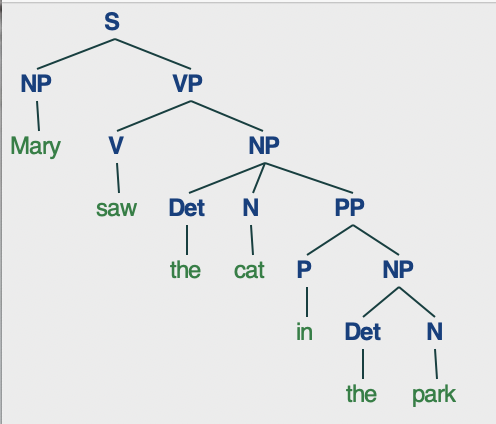 Tree 2: 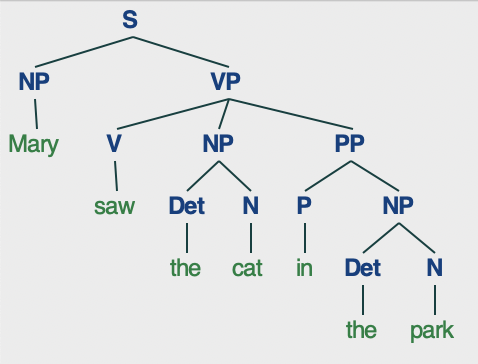 | Tree 1: 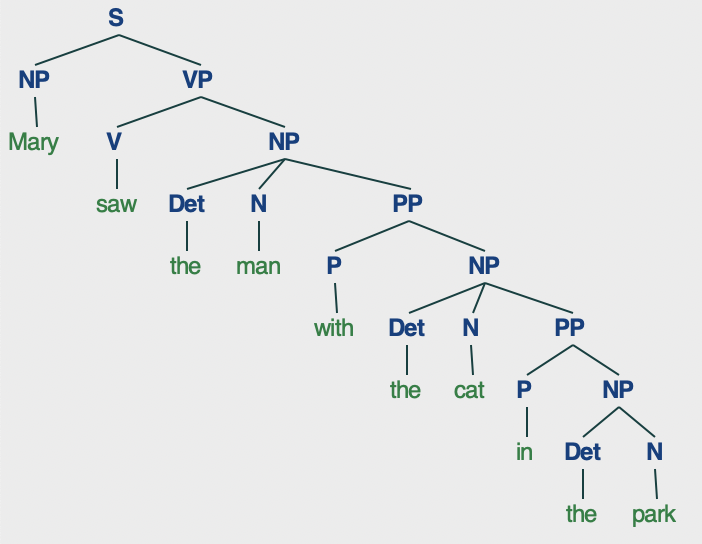 Tree 3: 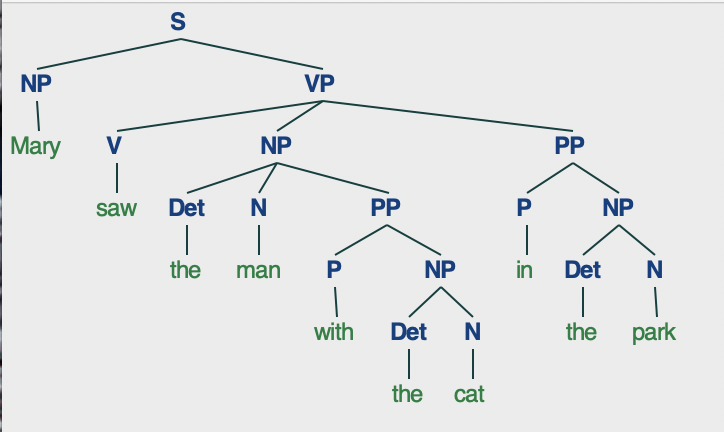 | Tree 5: 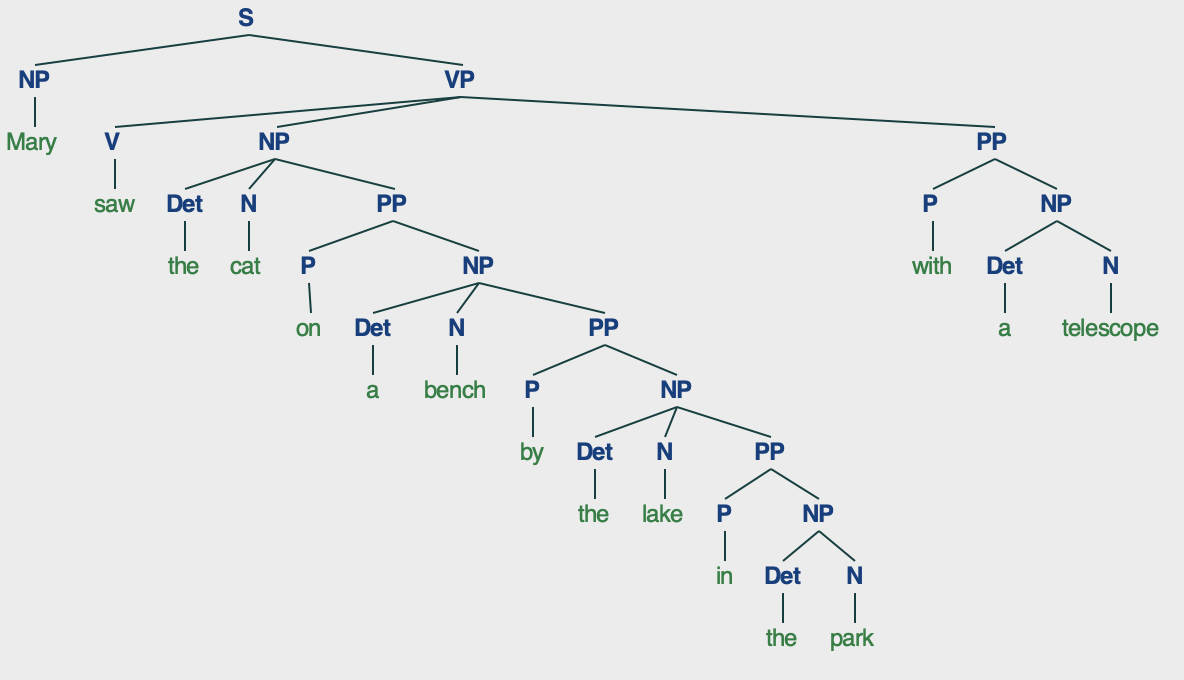 |

**Exercise 5.** Now we turn from phrase structure parsing to dependency parsing. NLTK does not include a dependency parser but it does provide a Python wrapper for the Stanford Dependency Parser. You can find instructions on how to use this parser and many more powerful tools [here](https://github.com/nltk/nltk/wiki/Stanford-CoreNLP-API-in-NLTK). Because this is not guaranteed to work on everyone's computer, we will use the parser provided by the [spaCy](https://spacy.io/usage) package. 

1. Install and import ```spacy```, including the English language model ```en_core_web_sm```. 
2. Now enter the four ambiguous sentences from the lecture (slide title: *Ambiguities are everwhere*) into this dependency parser and inspect the output. Place the output from the parser in a variable ```doc``` so that the code provided below prints out the dependencies and their labels. Is the sentence parsed correctly? You'll notice that the dependency labels that ```spacy``` uses are different from the universal dependencies from the lecture, but you should be able to decide on parsing correctness purely based on the arcs. Are these sentences parsed correctly, or not? Support your answers with an argument.
3. Import ```displacy``` and use ```displacy.render``` to visualize the dependency graph. Note, if you set ```jupyter=True``` the graph will be shown in the notebook, otherwise it will be shown on localhost:5000 in your browser.<div style="text-align: right">**(7 points)**</div>

In [17]:
# your code here
import spacy
from spacy import displacy

nlp = spacy.load("en_core_web_sm")

sentence1 = "San José cops kill man with a knife"
sentence2 = "Mutilated body washes up on Rio beach to be used for Olympics beach volleybal"
sentence3 = "Shuttle veteran and NASA executive Fred Gregory appointed to board"
sentence4 = "Students get first hand job experience"

doc1 = nlp(sentence1)
doc2 = nlp(sentence2)
doc3 = nlp(sentence3)
doc4 = nlp(sentence4)

doc_list = [doc1, doc2, doc3, doc4]

for doc in doc_list:
    print ("{:<15} | {:<8} | {:<15} | {:<20}".format('Word','Label','Head', 'Dependent'))
    print ("-" * 70)
    for token in doc:
      # Print the word, dependency label, head and all its dependents
      print ("{:<15} | {:<8} | {:<15} | {:<20}"
             .format(str(token.text), str(token.dep_), str(token.head.text), str([child for child in token.children])))

    # your code here
    displacy.render(doc, style="dep", jupyter=True)

Word            | Label    | Head            | Dependent           
----------------------------------------------------------------------
San             | compound | José            | []                  
José            | compound | cops            | [San]               
cops            | nsubj    | kill            | [José]              
kill            | ROOT     | kill            | [cops, man, with]   
man             | dobj     | kill            | []                  
with            | prep     | kill            | [knife]             
a               | det      | knife           | []                  
knife           | pobj     | with            | [a]                 


Word            | Label    | Head            | Dependent           
----------------------------------------------------------------------
Mutilated       | amod     | body            | []                  
body            | nsubj    | washes          | [Mutilated]         
washes          | ROOT     | washes          | [body, up, on, used]
up              | prt      | washes          | []                  
on              | prep     | washes          | [beach]             
Rio             | compound | beach           | []                  
beach           | pobj     | on              | [Rio]               
to              | aux      | used            | []                  
be              | auxpass  | used            | []                  
used            | advcl    | washes          | [to, be, for]       
for             | prep     | used            | [volleybal]         
Olympics        | compound | volleybal       | []                  
beach           | compound | volleybal       

Word            | Label    | Head            | Dependent           
----------------------------------------------------------------------
Shuttle         | compound | veteran         | []                  
veteran         | nsubj    | appointed       | [Shuttle, and, Gregory]
and             | cc       | veteran         | []                  
NASA            | compound | executive       | []                  
executive       | compound | Gregory         | [NASA]              
Fred            | compound | Gregory         | []                  
Gregory         | conj     | veteran         | [executive, Fred]   
appointed       | ROOT     | appointed       | [veteran, board]    
to              | aux      | board           | []                  
board           | xcomp    | appointed       | [to]                


Word            | Label    | Head            | Dependent           
----------------------------------------------------------------------
Students        | nsubj    | get             | []                  
get             | ROOT     | get             | [Students, experience]
first           | amod     | hand            | []                  
hand            | compound | experience      | [first]             
job             | compound | experience      | []                  
experience      | dobj     | get             | [hand, job]         


#### Answer Exercise 5:

**Sentence 1: San José cops kill man with a knife**
<br>This sentence is parsed correctly. This parse suggests that the cops killed a man using a knife. If the intended meaning is that the cops killed a man who had a knife, the parse is incorrect but since the sentence is ambiguous, it is not clear which meaning was intended.

**Sentence 2: Mutilated body washes up on Rio beach to be used for Olympics beach volleybal**
<br>Hopefully, this sentence means that the beach is used for the Olympics, and not the bodies. The parser however suggests that the bodies are used for the Olypics. Based on this, the parser is incorrect.

**Sentence 3: Shuttle veteran and NASA executive Fred Gregory appointed to board**
<br>The sentence is parsed correctly if Fred Gregory is both the NASA executive and the shuttle veteran.

**Sentence 4: Students get first hand job experience**
<br>The sentence is parsed correctly because "hand" is not modifying "job" but "experience". 